### Benchmark — DFT e FFT

In [1]:
import json
import time
import numpy as np
import matplotlib.pyplot as plt
import os

In [2]:
tamanhos = [16, 32, 64, 128, 256, 512, 1024, 2048]
REPETICOES = 5

tempos_numpy     = []

for N in tamanhos:
    np.random.seed(42)
    x = np.random.randn(N)
    medicoes = []
    for _ in range(REPETICOES):
        t0 = time.time()
        np.fft.fft(x)
        medicoes.append((time.time() - t0) * 1000)
    media_np = round(float(np.mean(medicoes)), 4)
    tempos_numpy.append(media_np)
    print(f"N = {N:5d} → {media_np:.4f} ms")
    
metricas = {
    "nome"       : "FFT Nunpy",
    "tamanhos"   : tamanhos,
    "tempos_ms"  : tempos_numpy
}

with open("numpy_fft_metrics.json", "w") as f:
    json.dump(metricas, f, indent=2)

print("\nSalvo em numpy_fft_metrics.json")

N =    16 → 7.5622 ms
N =    32 → 0.0060 ms
N =    64 → 0.0050 ms
N =   128 → 0.0040 ms
N =   256 → 0.0047 ms
N =   512 → 0.0064 ms
N =  1024 → 0.0089 ms
N =  2048 → 0.0167 ms

Salvo em numpy_fft_metrics.json


In [3]:
arquivos = [
    "dft_basica_metrics.json",
    "dft_matricial_metrics.json",
    "fft_radix2_metrics.json",
    "fft_geral_metrics.json",
    "numpy_fft_metrics.json",
]

dados = []
for arq in arquivos:
    if os.path.exists(arq):
        with open(arq) as f:
            dados.append(json.load(f))
        print(f"OK {arq}")
    else:
        print(f"FALTANDO {arq} - rode a celula de benchmark no notebook correspondente")

print(f"\n{len(dados)} de {len(arquivos)} arquivos carregados.")

OK dft_basica_metrics.json
OK dft_matricial_metrics.json
OK fft_radix2_metrics.json
OK fft_geral_metrics.json
OK numpy_fft_metrics.json

5 de 5 arquivos carregados.


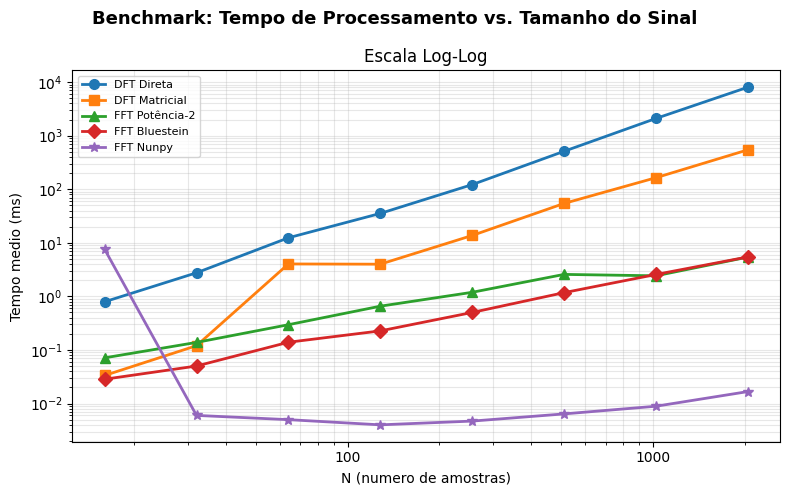

In [4]:

marcadores = {
    "DFT Direta"   : "o",
    "DFT Matricial": "s",
    "FFT Potência-2"  : "^",
    "FFT Bluestein": "D",
    "FFT Nunpy"    : "*",
}

fig, ax = plt.subplots(figsize=(8, 5))
fig.suptitle("Benchmark: Tempo de Processamento vs. Tamanho do Sinal",
                fontsize=13, fontweight="bold")

for d in dados:
    nome  = d["nome"]
    mkr   = marcadores.get(nome, "o")
    N_arr = np.array(d["tamanhos"][:len(d["tempos_ms"])])
    T_arr = np.array(d["tempos_ms"])
    label = f"{nome}"
    ax.loglog(N_arr, T_arr, marker=mkr, label=label, linewidth=2, markersize=7)

ax.set_title("Escala Log-Log")
ax.set_xlabel("N (numero de amostras)")
ax.set_ylabel("Tempo medio (ms)")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3, which="both")
ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())

plt.tight_layout()
plt.show()